In [1]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_rows",100)
pd.set_option("display.max_columns",100)

## Combine the data from all quarters from 2017 to 2019

In [2]:
for year in range(2017,2020):
    for quarter in range(1,5):    
        fname = "PUDF_base1_" + str(quarter) + "q" + str(year) + "_cleaned_train.csv"
        print(fname)
        df_tmp = pd.read_csv(fname, low_memory=False)

        df_tmp['SOURCE_OF_ADMISSION'] = df_tmp['SOURCE_OF_ADMISSION'].astype(str) # Remove rows with SOURCE_OF_ADMISSION = "`" (invalid value)
        df_tmp.drop(df_tmp[df_tmp["SOURCE_OF_ADMISSION"]=="`"].index,inplace=True)

        if quarter==1 and year==2017:
            df = df_tmp
        else:
            df = pd.concat([df, df_tmp], ignore_index=True) 
        del df_tmp

df.reset_index(drop=True, inplace=True)


PUDF_base1_1q2017_cleaned_train.csv
PUDF_base1_2q2017_cleaned_train.csv
PUDF_base1_3q2017_cleaned_train.csv
PUDF_base1_4q2017_cleaned_train.csv
PUDF_base1_1q2018_cleaned_train.csv
PUDF_base1_2q2018_cleaned_train.csv
PUDF_base1_3q2018_cleaned_train.csv
PUDF_base1_4q2018_cleaned_train.csv
PUDF_base1_1q2019_cleaned_train.csv
PUDF_base1_2q2019_cleaned_train.csv
PUDF_base1_3q2019_cleaned_train.csv
PUDF_base1_4q2019_cleaned_train.csv


## Cleaning the data

We set the data types of the categorical data.
We also introduced two additional variables.

In [3]:
df["TYPE_OF_ADMISSION"] = df["TYPE_OF_ADMISSION"].astype(int).astype(str)
df["PUBLIC_HEALTH_REGION"] = df["PUBLIC_HEALTH_REGION"].astype(int).astype(str)
df["RACE"] = df["RACE"].astype(int).astype(str)
df["ETHNICITY"] = df["ETHNICITY"].astype(int).astype(str)
df["ADMIT_WEEKDAY"] = df["ADMIT_WEEKDAY"].astype(int).astype(str)

df["PROLONGED"] = [1 if los >= 30 else 0 for los in df["LENGTH_OF_STAY"]] # Create prolonged stay indicator variable
df["NUM_CODES"] = df[["CODE_"+str(n) for n in range(1,22)]].sum(axis=1) # Count number of diagnosis codes for each patient

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5605266 entries, 0 to 5605265
Data columns (total 48 columns):
 #   Column                Dtype  
---  ------                -----  
 0   RECORD_ID             int64  
 1   THCIC_ID              int64  
 2   TYPE_OF_ADMISSION     object 
 3   SOURCE_OF_ADMISSION   object 
 4   PUBLIC_HEALTH_REGION  object 
 5   PAT_STATUS            int64  
 6   SEX_CODE              object 
 7   RACE                  object 
 8   ETHNICITY             object 
 9   ADMIT_WEEKDAY         object 
 10  LENGTH_OF_STAY        float64
 11  PAT_AGE               int64  
 12  EMERGENCY_DEPT_FLAG   object 
 13  DIAG_CODES_OA         object 
 14  CODE_1                int64  
 15  CODE_2                int64  
 16  CODE_3                int64  
 17  CODE_4                int64  
 18  CODE_5                int64  
 19  CODE_6                int64  
 20  CODE_7                int64  
 21  CODE_8                int64  
 22  CODE_9                int64  
 23  CODE_10

Remove feature columns not needed for training -- RECORD_ID, THCIC_ID, PAT_ZIP, PAT_STATE, PAT_COUNTRY, PAT_COUNTY, DIAG_CODES_OA, PROVIDER_ZIP, CODE_22, PAT_STATUS

In [4]:
redundant_features = ["RECORD_ID", "THCIC_ID", "PAT_ZIP", "PAT_STATE", "PAT_COUNTRY","PAT_COUNTY", "DIAG_CODES_OA", "PROVIDER_ZIP", "CODE_22","PAT_STATUS"]

for feature in redundant_features:
    if feature in df.columns:
        df.drop(columns=[feature], inplace=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5605266 entries, 0 to 5605265
Data columns (total 43 columns):
 #   Column                Dtype  
---  ------                -----  
 0   TYPE_OF_ADMISSION     object 
 1   SOURCE_OF_ADMISSION   object 
 2   PUBLIC_HEALTH_REGION  object 
 3   SEX_CODE              object 
 4   RACE                  object 
 5   ETHNICITY             object 
 6   ADMIT_WEEKDAY         object 
 7   LENGTH_OF_STAY        float64
 8   PAT_AGE               int64  
 9   EMERGENCY_DEPT_FLAG   object 
 10  CODE_1                int64  
 11  CODE_2                int64  
 12  CODE_3                int64  
 13  CODE_4                int64  
 14  CODE_5                int64  
 15  CODE_6                int64  
 16  CODE_7                int64  
 17  CODE_8                int64  
 18  CODE_9                int64  
 19  CODE_10               int64  
 20  CODE_11               int64  
 21  CODE_12               int64  
 22  CODE_13               int64  
 23  CODE_14

Merge two lowest patient age groups

In [5]:
df.loc[df["PAT_AGE"]==0,"PAT_AGE"] = 1

In [6]:
df["EMERGENCY_DEPT_FLAG"] = df["EMERGENCY_DEPT_FLAG"].map({"Y":1,"N":0})

## Create pipeline for preprocessing and validation

In [7]:
categorical_cols = ["TYPE_OF_ADMISSION", "SOURCE_OF_ADMISSION", "PUBLIC_HEALTH_REGION", "SEX_CODE", "RACE", "ETHNICITY"]

Split data for training and testing

In [8]:
# Import Metrics
from sklearn.metrics import mean_absolute_error 
from sklearn.metrics import root_mean_squared_error 
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold

TRAIN_FLAG = True

df['STRATA'] = df['QUARTER'].astype(str) + '_' + df['PAT_RURAL'].astype(str) + '_' + df['PROVIDER_RURAL'].astype(str) # for stratification sampling

if not TRAIN_FLAG:
# df_small = df.sample(n=2000000, random_state=42)
    df_small = df

    y = df_small["LENGTH_OF_STAY"]
    X = df_small.drop(columns=["LENGTH_OF_STAY","PROLONGED","STRATA"])

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify = df_small['STRATA']
    )
else:
    X_train = df.drop(columns=["LENGTH_OF_STAY","PROLONGED","STRATA"])
    y_train = df["LENGTH_OF_STAY"]

In [9]:
# Create the StratifiedKFold
strata_train = df.loc[X_train.index, "STRATA"]

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=2222
)

In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
# from cuml.ensemble import RandomForestRegressor

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols)
    ],
    remainder="passthrough"  # Keeps the 'age' column untouched
)

model_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    # ('rf_gpu', RandomForestRegressor(n_estimators=100))
    ("regressor", RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=64)) # Use 64 processing cores for parallel processing
])


## Hyperparameter tuning

We find the best value of n_estimators in the RandomForestRegressor using Bayesian optimization

In [11]:
from skopt import BayesSearchCV
from skopt.space import Integer, Categorical
import random

search_space = {
    'regressor__n_estimators': Integer(50, 300)
}

bayes_search = BayesSearchCV(
    estimator=model_pipeline,           # Pass the complete pipeline here
    search_spaces=search_space,   # Pass the prefixed search space
    n_iter=22,                    # Total parameter evaluations
    cv=5,                         # Cross-validation splits
    scoring='neg_mean_squared_error',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random.seed(42)  # Set seed for reproducibility
random_indices = random.sample(range(len(y_train)), 100_000)  # Randomly sample 100,000 indices
random_indices.sort()
# random_indices

bayes_search.fit(X_train.iloc[random_indices,:], y_train.iloc[random_indices])

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fi

,estimator,Pipeline(step...m_state=42))])
,search_spaces,{'regressor__n_estimators': Integer(low=5...m='normalize')}
,optimizer_kwargs,None
,n_iter,22
,scoring,'neg_mean_squared_error'
,fit_params,None
,n_jobs,-1
,n_points,1
,iid,'deprecated'
,refit,True
,cv,5


In [12]:
print(f"\nBest CV Negative MSE: {bayes_search.best_score_:.4f}")
# Strip the 'regressor__' prefix when printing for clean viewing
best_params = {k.replace('regressor__', ''): v for k, v in bayes_search.best_params_.items()}
print(f"Best Hyperparameters: {best_params}")



Best CV Negative MSE: -254.2518
Best Hyperparameters: {'n_estimators': 187}


In [13]:
model_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    # ('rf_gpu', RandomForestRegressor(n_estimators=100))
    ("regressor", RandomForestRegressor(n_estimators=best_params["n_estimators"], random_state=42, n_jobs=64)) # Use 64 processing cores for parallel processing
])


## Data training and metrics

In [14]:
mae_scores = []
rmse_scores = []

for fold, (train_idx, valid_idx) in enumerate(skf.split(X_train, strata_train)):
    X_tr = X_train.iloc[train_idx].copy()
    X_val = X_train.iloc[valid_idx].copy()
    y_tr = y_train.iloc[train_idx]
    y_val = y_train.iloc[valid_idx]

    model_pipeline.fit(X_tr, y_tr)
    pred_y = model_pipeline.predict(X_val)

    mae_score = mean_absolute_error(y_val, pred_y)
    rmse_score = root_mean_squared_error(y_val, pred_y)

    mae_scores.append(mae_score)
    rmse_scores.append(rmse_score)

    print(f"Fold {fold + 1}: MAE = {mae_score}, RMSE = {rmse_score}")

Fold 1: MAE = 3.242841189472245, RMSE = 12.046409641843686
Fold 2: MAE = 3.26787556624551, RMSE = 15.865849117497696
Fold 3: MAE = 3.2790726959466188, RMSE = 16.344159475186206
Fold 4: MAE = 3.2613311689655533, RMSE = 14.876085755778613
Fold 5: MAE = 3.2453575464428477, RMSE = 13.574340553722305


In [45]:
import numpy as np
print(f"Mean MAE = {np.array(mae_scores).mean():.4f}, Mean RMSE = {np.array(rmse_scores).mean():.4f}")

Mean MAE = 3.2593, Mean RMSE = 14.5414


In [46]:
array1 = model_pipeline.named_steps['preprocessor'].get_feature_names_out() # name of the features after one-hot encoding
array2 = model_pipeline.named_steps['regressor'].feature_importances_ # importance of the features after one-hot encoding

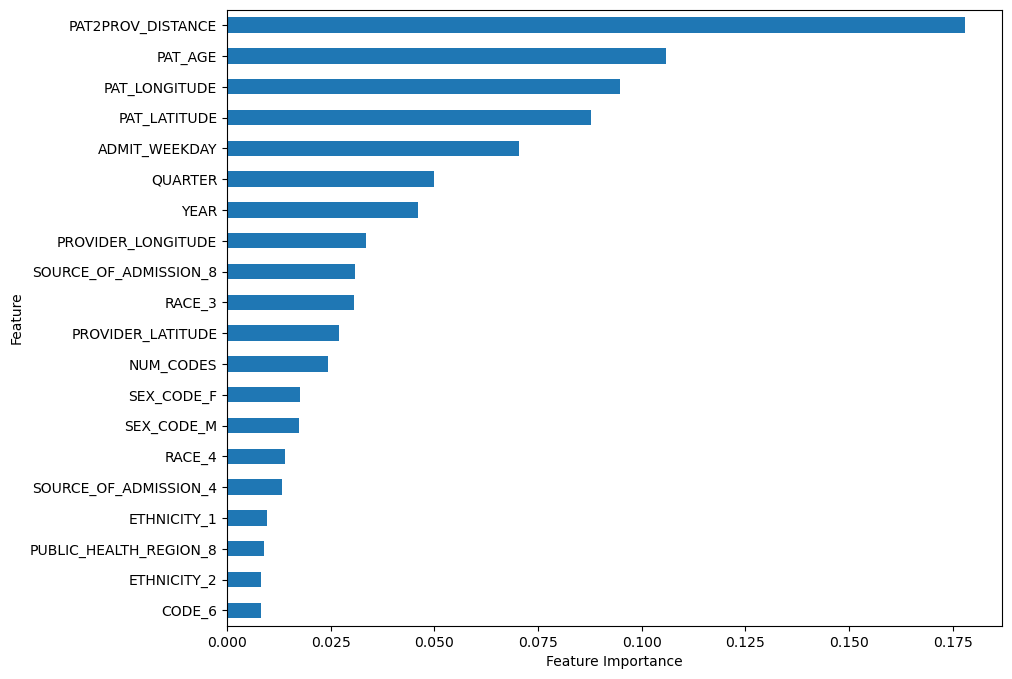

In [47]:

feature_importance = pd.DataFrame({'Feature': array1, 'Importance': array2})
feature_importance.sort_values(by='Importance', ascending=True, inplace=True)
feature_importance["Feature"] = feature_importance["Feature"].apply(lambda x: x.split("__")[1] if "__" in x else x)
feature_importance.tail(20).plot.barh(x='Feature', y='Importance', figsize=(10, 8), legend=False)
plt.xlabel("Feature Importance")
plt.show()

## Final Testing

We train on the full training dataset

In [51]:
model_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers conta

In [52]:
for year in range(2017,2020):
    for quarter in range(1,5):    
        fname = "PUDF_base1_" + str(quarter) + "q" + str(year) + "_cleaned_test.csv"
        print(fname)
        df_tmp = pd.read_csv(fname, low_memory=False)

        df_tmp['SOURCE_OF_ADMISSION'] = df_tmp['SOURCE_OF_ADMISSION'].astype(str) # Remove rows with SOURCE_OF_ADMISSION = "`" (invalid value)
        df_tmp.drop(df_tmp[df_tmp["SOURCE_OF_ADMISSION"]=="`"].index,inplace=True)

        if quarter==1 and year==2017:
            df = df_tmp
        else:
            df = pd.concat([df, df_tmp], ignore_index=True) 
        del df_tmp

df.reset_index(drop=True, inplace=True)


PUDF_base1_1q2017_cleaned_test.csv
PUDF_base1_2q2017_cleaned_test.csv
PUDF_base1_3q2017_cleaned_test.csv
PUDF_base1_4q2017_cleaned_test.csv
PUDF_base1_1q2018_cleaned_test.csv
PUDF_base1_2q2018_cleaned_test.csv
PUDF_base1_3q2018_cleaned_test.csv
PUDF_base1_4q2018_cleaned_test.csv
PUDF_base1_1q2019_cleaned_test.csv
PUDF_base1_2q2019_cleaned_test.csv
PUDF_base1_3q2019_cleaned_test.csv
PUDF_base1_4q2019_cleaned_test.csv


In [53]:
df["TYPE_OF_ADMISSION"] = df["TYPE_OF_ADMISSION"].astype(int).astype(str)
df["PUBLIC_HEALTH_REGION"] = df["PUBLIC_HEALTH_REGION"].astype(int).astype(str)
df["RACE"] = df["RACE"].astype(int).astype(str)
df["ETHNICITY"] = df["ETHNICITY"].astype(int).astype(str)
df["ADMIT_WEEKDAY"] = df["ADMIT_WEEKDAY"].astype(int).astype(str)

df["PROLONGED"] = [1 if los >= 30 else 0 for los in df["LENGTH_OF_STAY"]] # Create prolonged stay indicator variable
df["NUM_CODES"] = df[["CODE_"+str(n) for n in range(1,22)]].sum(axis=1) # Count number of diagnosis codes for each patient

In [54]:
redundant_features = ["RECORD_ID", "THCIC_ID", "PAT_ZIP", "PAT_STATE", "PAT_COUNTRY","PAT_COUNTY", "DIAG_CODES_OA", "PROVIDER_ZIP", "CODE_22","PAT_STATUS"]

for feature in redundant_features:
    if feature in df.columns:
        df.drop(columns=[feature], inplace=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1401317 entries, 0 to 1401316
Data columns (total 42 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   TYPE_OF_ADMISSION     1401317 non-null  object 
 1   SOURCE_OF_ADMISSION   1401317 non-null  object 
 2   PUBLIC_HEALTH_REGION  1401317 non-null  object 
 3   SEX_CODE              1401317 non-null  object 
 4   RACE                  1401317 non-null  object 
 5   ETHNICITY             1401317 non-null  object 
 6   ADMIT_WEEKDAY         1401317 non-null  object 
 7   LENGTH_OF_STAY        1401317 non-null  float64
 8   PAT_AGE               1401317 non-null  int64  
 9   EMERGENCY_DEPT_FLAG   1401317 non-null  object 
 10  CODE_1                1401317 non-null  int64  
 11  CODE_2                1401317 non-null  int64  
 12  CODE_3                1401317 non-null  int64  
 13  CODE_4                1401317 non-null  int64  
 14  CODE_5                1401317 non-

In [55]:
df.loc[df["PAT_AGE"]==0,"PAT_AGE"] = 1
df["EMERGENCY_DEPT_FLAG"] = df["EMERGENCY_DEPT_FLAG"].map({"Y":1,"N":0})

In [ ]:
X_test = df.drop(columns=["LENGTH_OF_STAY","PROLONGED"]) # testing data for model evaluation
y_test = df["LENGTH_OF_STAY"] 

In [64]:
pred_y = model_pipeline.predict(X_test)
mae_score = mean_absolute_error(y_test, pred_y)
rmse_score = root_mean_squared_error(y_test, pred_y)
print(f"Final MAE = {mae_score}, RMSE = {rmse_score} for random forest regressor model.")

Final MAE = 3.24802089166817, RMSE = 12.351487135572185 for random forest regressor model.
